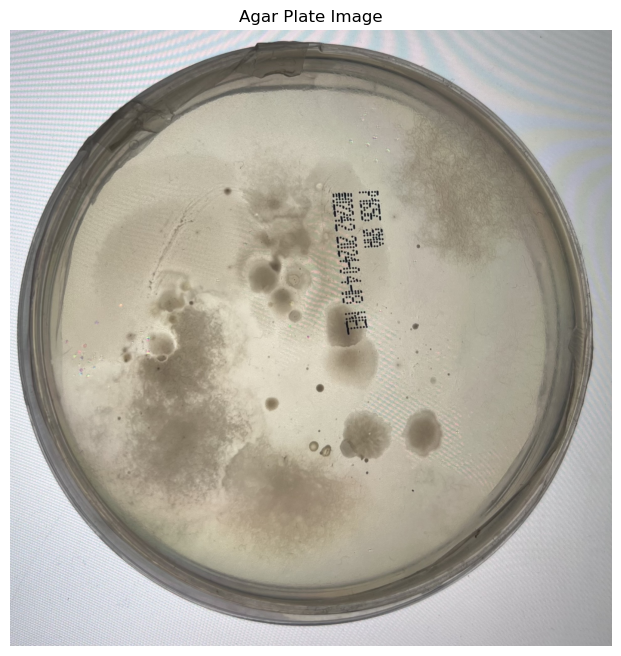

Successfully loaded image: agar1.jpg
Image dimensions: (1967, 1920, 3)


In [1]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image_path = "agar1.jpg"
img = cv2.imread(image_path)

# Check if image was loaded successfully
if img is None:
    print(f"Error: Could not load image from {image_path}")
else:
    # Convert from BGR (OpenCV default) to RGB for correct color display
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Display the image
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title("Agar Plate Image")
    plt.axis('off')  # Hide axis
    plt.show()
    
    print(f"Successfully loaded image: {image_path}")
    print(f"Image dimensions: {img.shape}")

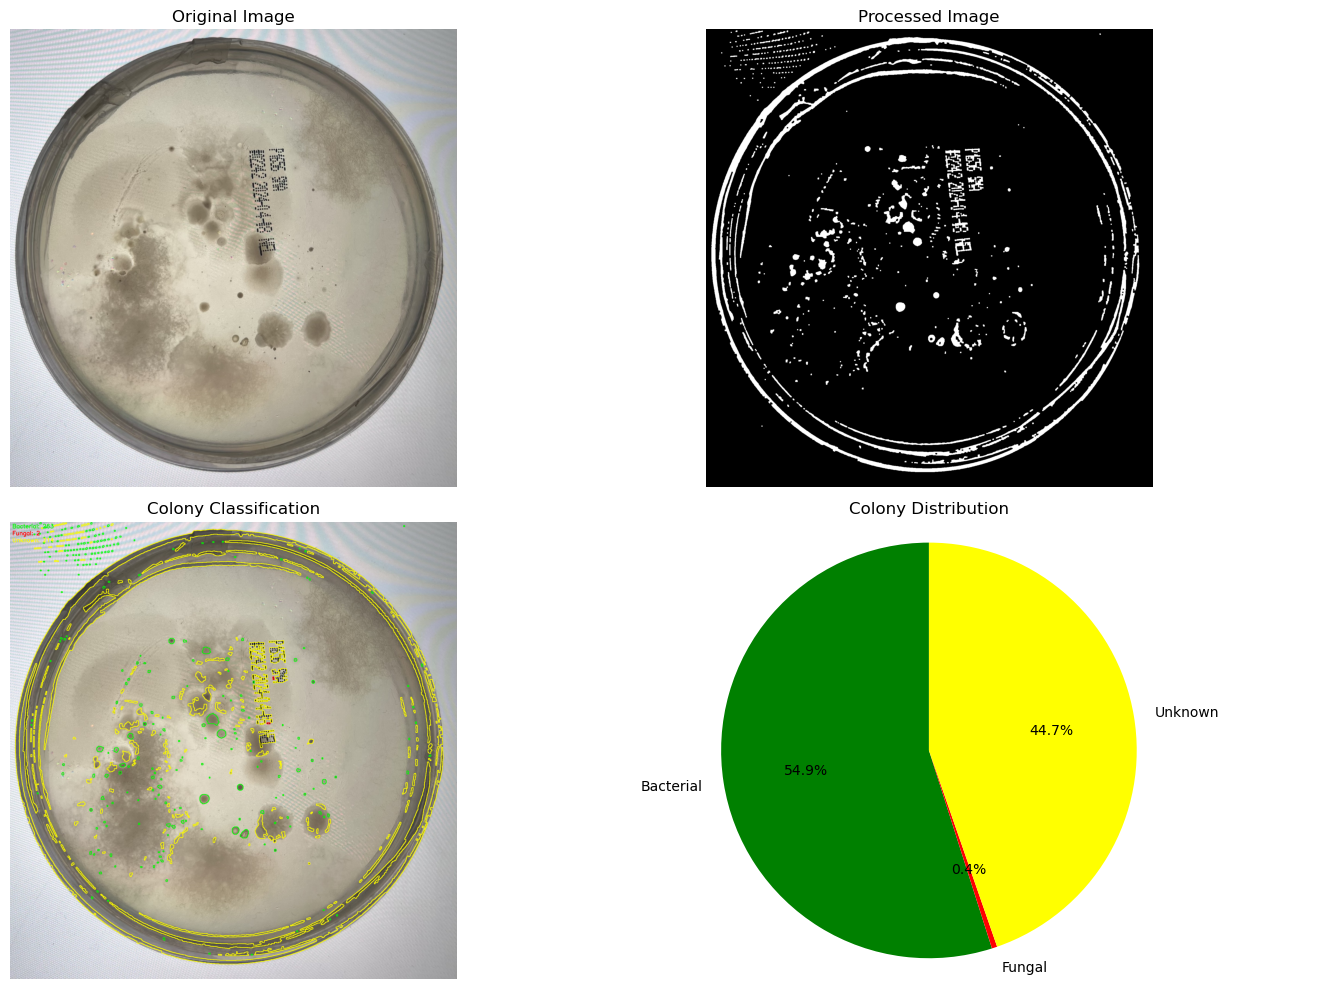

Analysis Results for agar1.jpg:
Total colonies detected: 479
Bacterial colonies: 263
Fungal colonies: 2
Unknown colonies: 214
Average bacterial colony size: 79.12 pixels
Average fungal colony size: 63.75 pixels


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

# Load the image
image_path = "agar1.jpg"
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image from {image_path}")
    exit()

# Convert to RGB for visualization
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale for processing
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply adaptive thresholding to handle uneven lighting
thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 101, 10
)

# Remove small noise and fill holes in colonies
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)

# Find the circular plate region (if visible in the image)
circles = cv2.HoughCircles(
    gray, cv2.HOUGH_GRADIENT, 1, gray.shape[0]//8,
    param1=100, param2=30,
    minRadius=min(gray.shape)//4,
    maxRadius=min(gray.shape)//2
)

# Create a mask for the plate region
mask = np.zeros_like(gray)
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(mask, (i[0], i[1]), i[2], 255, -1)
else:
    # If no circle detected, use a default circular mask
    center_x, center_y = gray.shape[1] // 2, gray.shape[0] // 2
    radius = min(gray.shape) // 2 - 10
    cv2.circle(mask, (center_x, center_y), radius, 255, -1)

# Apply the mask to the processed image
masked_closing = cv2.bitwise_and(closing, closing, mask=mask)

# Find contours (potential colonies)
contours, _ = cv2.findContours(masked_closing, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours based on size
min_colony_area = 20  # Adjust based on your image scale
contours = [cnt for cnt in contours if cv2.contourArea(cnt) >= min_colony_area]

def extract_texture_features(gray_img, contour):
    """Extract texture features for a given contour."""
    # Create a mask for the contour
    mask = np.zeros_like(gray_img)
    cv2.drawContours(mask, [contour], 0, 255, -1)
    
    # Apply mask to the grayscale image
    roi = cv2.bitwise_and(gray_img, mask)
    
    # Find non-zero points in the ROI
    nonzero = np.where(roi > 0)
    if len(nonzero[0]) == 0:
        return None
        
    y_min, y_max = np.min(nonzero[0]), np.max(nonzero[0])
    x_min, x_max = np.min(nonzero[1]), np.max(nonzero[1])
    
    # Extract the ROI
    if y_max > y_min and x_max > x_min:
        roi_cropped = gray_img[y_min:y_max+1, x_min:x_max+1]
        
        # Calculate GLCM for texture analysis
        if roi_cropped.size > 0:
            # Normalize to fewer gray levels to make GLCM computation faster
            roi_normalized = (roi_cropped / 16).astype(np.uint8)
            
            try:
                glcm = graycomatrix(roi_normalized, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], 
                                    levels=16, symmetric=True, normed=True)
                
                # Extract texture properties
                contrast = graycoprops(glcm, 'contrast').mean()
                dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
                homogeneity = graycoprops(glcm, 'homogeneity').mean()
                energy = graycoprops(glcm, 'energy').mean()
                correlation = graycoprops(glcm, 'correlation').mean()
                
                return {
                    'contrast': contrast,
                    'dissimilarity': dissimilarity,
                    'homogeneity': homogeneity,
                    'energy': energy,
                    'correlation': correlation
                }
            except:
                return None
    
    return None

def classify_colony_type(contour, gray_img):
    """Determine if a contour is likely bacterial or fungal."""
    # Extract shape features
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    
    # Circularity: 4π(Area/Perimeter²) - closer to 1 means more circular
    circularity = 0
    if perimeter > 0:
        circularity = 4 * np.pi * (area / (perimeter * perimeter))
    
    # Extract texture features
    texture_features = extract_texture_features(gray_img, contour)
    
    # Classification rules based on features
    if texture_features is None:
        return "unknown"
    
    # Bacteria tend to have smoother texture and more circular shape
    if (circularity > 0.7 and 
        texture_features['homogeneity'] > 0.5 and 
        texture_features['energy'] > 0.2):
        return "bacterial"
    # Fungi often have irregular shapes and rougher textures
    elif (circularity < 0.7 and 
          texture_features['contrast'] > 0.5 and 
          texture_features['homogeneity'] < 0.5):
        return "fungal"
    else:
        return "unknown"

# Analyze each colony
bacterial_colonies = []
fungal_colonies = []
unknown_colonies = []

for contour in contours:
    colony_type = classify_colony_type(contour, gray)
    area = cv2.contourArea(contour)
    
    if colony_type == "bacterial":
        bacterial_colonies.append((contour, area))
    elif colony_type == "fungal":
        fungal_colonies.append((contour, area))
    else:
        unknown_colonies.append((contour, area))

# Create a copy of the original image for visualization
vis_img = img_rgb.copy()

# Draw bacterial colonies in green
cv2.drawContours(vis_img, [cnt for cnt, _ in bacterial_colonies], -1, (0, 255, 0), 2)

# Draw fungal colonies in red
cv2.drawContours(vis_img, [cnt for cnt, _ in fungal_colonies], -1, (255, 0, 0), 2)

# Draw unknown colonies in yellow
cv2.drawContours(vis_img, [cnt for cnt, _ in unknown_colonies], -1, (255, 255, 0), 2)

# Add text with counts
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(vis_img, f'Bacterial: {len(bacterial_colonies)}', 
           (10, 30), font, 0.8, (0, 255, 0), 2)
cv2.putText(vis_img, f'Fungal: {len(fungal_colonies)}', 
           (10, 60), font, 0.8, (255, 0, 0), 2)
cv2.putText(vis_img, f'Unknown: {len(unknown_colonies)}', 
           (10, 90), font, 0.8, (255, 255, 0), 2)

# Display results
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(masked_closing, cmap='gray')
plt.title('Processed Image')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(vis_img)
plt.title('Colony Classification')
plt.axis('off')

plt.subplot(2, 2, 4)
# Create a pie chart of colony distribution
labels = ['Bacterial', 'Fungal', 'Unknown']
sizes = [len(bacterial_colonies), len(fungal_colonies), len(unknown_colonies)]
colors = ['green', 'red', 'yellow']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Colony Distribution')

plt.tight_layout()
plt.show()

# Print detailed results
print(f"Analysis Results for {image_path}:")
print(f"Total colonies detected: {len(contours)}")
print(f"Bacterial colonies: {len(bacterial_colonies)}")
print(f"Fungal colonies: {len(fungal_colonies)}")
print(f"Unknown colonies: {len(unknown_colonies)}")

if bacterial_colonies:
    avg_bacterial_size = sum(area for _, area in bacterial_colonies) / len(bacterial_colonies)
    print(f"Average bacterial colony size: {avg_bacterial_size:.2f} pixels")

if fungal_colonies:
    avg_fungal_size = sum(area for _, area in fungal_colonies) / len(fungal_colonies)
    print(f"Average fungal colony size: {avg_fungal_size:.2f} pixels")

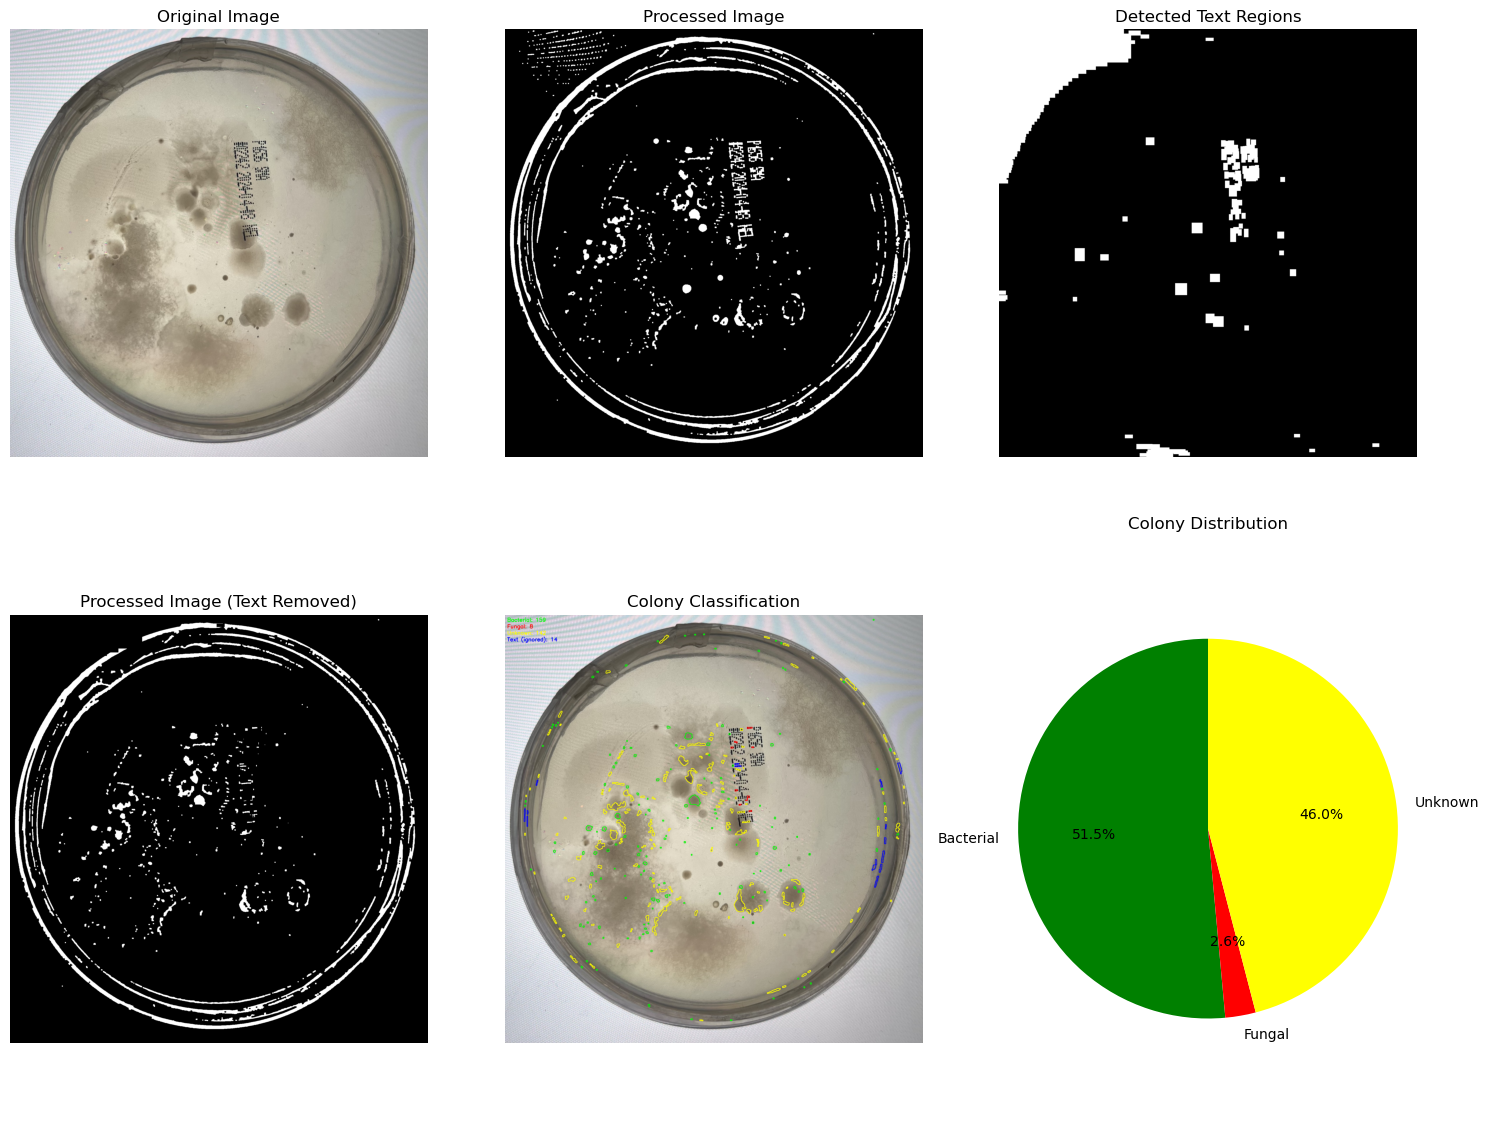

Analysis Results for agar1.jpg:
Total colonies detected: 309
Bacterial colonies: 159
Fungal colonies: 8
Unknown colonies: 142
Text regions identified and ignored: 14
Average bacterial colony size: 74.66 pixels
Average fungal colony size: 74.00 pixels


In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import graycomatrix, graycoprops

# Load the image
image_path = "agar1.jpg"
img = cv2.imread(image_path)

if img is None:
    print(f"Error: Could not load image from {image_path}")
    exit()

# Convert to RGB for visualization
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert to grayscale for processing
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Apply Gaussian blur to reduce noise
blurred = cv2.GaussianBlur(gray, (5, 5), 0)

# Apply adaptive thresholding to handle uneven lighting
thresh = cv2.adaptiveThreshold(
    blurred, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, 
    cv2.THRESH_BINARY_INV, 101, 10
)

# Remove small noise and fill holes in colonies
kernel = np.ones((3, 3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel, iterations=2)

# Find the circular plate region (if visible in the image)
circles = cv2.HoughCircles(
    gray, cv2.HOUGH_GRADIENT, 1, gray.shape[0]//8,
    param1=100, param2=30,
    minRadius=min(gray.shape)//4,
    maxRadius=min(gray.shape)//2
)

# Create a mask for the plate region
mask = np.zeros_like(gray)
if circles is not None:
    circles = np.uint16(np.around(circles))
    for i in circles[0, :]:
        cv2.circle(mask, (i[0], i[1]), i[2], 255, -1)
else:
    # If no circle detected, use a default circular mask
    center_x, center_y = gray.shape[1] // 2, gray.shape[0] // 2
    radius = min(gray.shape) // 2 - 10
    cv2.circle(mask, (center_x, center_y), radius, 255, -1)

# Apply the mask to the processed image
masked_closing = cv2.bitwise_and(closing, closing, mask=mask)

# Generate a text detection mask to filter out serial numbers
text_mask = np.zeros_like(gray)
try:
    # Use text detection techniques to identify potential text regions
    # Method 1: Use morphological operations to identify linear structures
    # that are characteristic of text
    
    # Create a rectangle kernel for text detection
    rect_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (15, 3))
    
    # Apply dilation to connect text characters
    text_regions = cv2.dilate(thresh, rect_kernel, iterations=1)
    
    # Find contours of potential text regions
    text_contours, _ = cv2.findContours(text_regions, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Filter contours based on aspect ratio and size to identify text
    for contour in text_contours:
        x, y, w, h = cv2.boundingRect(contour)
        
        # Text regions typically have width > height and certain area constraints
        aspect_ratio = float(w) / h
        area = cv2.contourArea(contour)
        
        # These parameters identify horizontal text lines
        if aspect_ratio > 2.5 and 100 < area < 10000:
            # Draw the text region on the mask
            cv2.rectangle(text_mask, (x, y), (x+w, y+h), 255, -1)
            
    # Alternative Method 2: MSER (Maximally Stable Extremal Regions)
    # MSER works well for detecting text regions
    try:
        mser = cv2.MSER_create()
        mser.setMinArea(100)  # Min area of text component
        mser.setMaxArea(2000)  # Max area of text component
        
        # Detect regions
        regions, _ = mser.detectRegions(gray)
        
        for region in regions:
            # Create bounding box
            x, y, w, h = cv2.boundingRect(region)
            aspect_ratio = float(w) / h
            
            # Filter text-like regions
            if 0.1 < aspect_ratio < 10:  # Text can be horizontal or vertical
                cv2.rectangle(text_mask, (x, y), (x+w, y+h), 255, -1)
    except:
        print("MSER text detection failed, continuing with other methods")
            
except Exception as e:
    print(f"Text detection failed: {e}. Continuing without text filtering.")

# Dilate the text mask to ensure complete coverage of text areas
text_mask = cv2.dilate(text_mask, np.ones((5,5), np.uint8), iterations=2)

# Invert the text mask and apply it to the colony mask 
# (0 in text areas, 1 elsewhere)
inverted_text_mask = cv2.bitwise_not(text_mask)
masked_closing_no_text = cv2.bitwise_and(masked_closing, masked_closing, mask=inverted_text_mask)

# Find contours (potential colonies) after filtering out text
contours, _ = cv2.findContours(masked_closing_no_text, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours based on size and shape
min_colony_area = 20  # Adjust based on your image scale
filtered_contours = []

for contour in contours:
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    
    # Skip if area is too small
    if area < min_colony_area:
        continue
    
    # Calculate circularity
    circularity = 0
    if perimeter > 0:
        circularity = 4 * np.pi * (area / (perimeter * perimeter))
    
    # Text and numbers tend to have very low circularity
    # and often form long, thin shapes
    if circularity > 0.2:  # Adjust this threshold as needed
        filtered_contours.append(contour)

def extract_texture_features(gray_img, contour):
    """Extract texture features for a given contour."""
    # Create a mask for the contour
    mask = np.zeros_like(gray_img)
    cv2.drawContours(mask, [contour], 0, 255, -1)
    
    # Apply mask to the grayscale image
    roi = cv2.bitwise_and(gray_img, mask)
    
    # Find non-zero points in the ROI
    nonzero = np.where(roi > 0)
    if len(nonzero[0]) == 0:
        return None
        
    y_min, y_max = np.min(nonzero[0]), np.max(nonzero[0])
    x_min, x_max = np.min(nonzero[1]), np.max(nonzero[1])
    
    # Extract the ROI
    if y_max > y_min and x_max > x_min:
        roi_cropped = gray_img[y_min:y_max+1, x_min:x_max+1]
        
        # Calculate GLCM for texture analysis
        if roi_cropped.size > 0:
            # Normalize to fewer gray levels to make GLCM computation faster
            roi_normalized = (roi_cropped / 16).astype(np.uint8)
            
            try:
                glcm = graycomatrix(roi_normalized, [1], [0, np.pi/4, np.pi/2, 3*np.pi/4], 
                                    levels=16, symmetric=True, normed=True)
                
                # Extract texture properties
                contrast = graycoprops(glcm, 'contrast').mean()
                dissimilarity = graycoprops(glcm, 'dissimilarity').mean()
                homogeneity = graycoprops(glcm, 'homogeneity').mean()
                energy = graycoprops(glcm, 'energy').mean()
                correlation = graycoprops(glcm, 'correlation').mean()
                
                return {
                    'contrast': contrast,
                    'dissimilarity': dissimilarity,
                    'homogeneity': homogeneity,
                    'energy': energy,
                    'correlation': correlation
                }
            except:
                return None
    
    return None

def is_likely_text(contour, gray_img):
    """Additional check to determine if a contour is likely text."""
    x, y, w, h = cv2.boundingRect(contour)
    
    # Text typically has high aspect ratio
    aspect_ratio = float(w) / h
    
    # Extract ROI
    roi = gray_img[y:y+h, x:x+w]
    
    # Text often has high variance in horizontal direction
    # and low variance in vertical direction
    if roi.size == 0:
        return False
    
    try:
        # Calculate horizontal and vertical gradients
        sobelx = cv2.Sobel(roi, cv2.CV_64F, 1, 0, ksize=3)
        sobely = cv2.Sobel(roi, cv2.CV_64F, 0, 1, ksize=3)
        
        # Text has strong horizontal gradients
        horizontal_energy = np.sum(np.abs(sobelx))
        vertical_energy = np.sum(np.abs(sobely))
        
        # For text, horizontal gradients are typically stronger
        gradient_ratio = horizontal_energy / (vertical_energy + 1e-6)
        
        return (aspect_ratio > 2.0 or aspect_ratio < 0.5) and gradient_ratio > 1.5
    except:
        return False

def classify_colony_type(contour, gray_img):
    """Determine if a contour is likely bacterial or fungal."""
    # First check if it's likely text
    if is_likely_text(contour, gray_img):
        return "text"
    
    # Extract shape features
    area = cv2.contourArea(contour)
    perimeter = cv2.arcLength(contour, True)
    
    # Circularity: 4π(Area/Perimeter²) - closer to 1 means more circular
    circularity = 0
    if perimeter > 0:
        circularity = 4 * np.pi * (area / (perimeter * perimeter))
    
    # Extract texture features
    texture_features = extract_texture_features(gray_img, contour)
    
    # Classification rules based on features
    if texture_features is None:
        return "unknown"
    
    # Bacteria tend to have smoother texture and more circular shape
    if (circularity > 0.7 and 
        texture_features['homogeneity'] > 0.5 and 
        texture_features['energy'] > 0.2):
        return "bacterial"
    # Fungi often have irregular shapes and rougher textures
    elif (circularity < 0.7 and 
          texture_features['contrast'] > 0.5 and 
          texture_features['homogeneity'] < 0.5):
        return "fungal"
    else:
        return "unknown"

# Analyze each colony
bacterial_colonies = []
fungal_colonies = []
unknown_colonies = []
text_regions = []

for contour in filtered_contours:
    colony_type = classify_colony_type(contour, gray)
    area = cv2.contourArea(contour)
    
    if colony_type == "bacterial":
        bacterial_colonies.append((contour, area))
    elif colony_type == "fungal":
        fungal_colonies.append((contour, area))
    elif colony_type == "text":
        text_regions.append(contour)
    else:
        unknown_colonies.append((contour, area))

# Create a copy of the original image for visualization
vis_img = img_rgb.copy()

# Draw bacterial colonies in green
cv2.drawContours(vis_img, [cnt for cnt, _ in bacterial_colonies], -1, (0, 255, 0), 2)

# Draw fungal colonies in red
cv2.drawContours(vis_img, [cnt for cnt, _ in fungal_colonies], -1, (255, 0, 0), 2)

# Draw unknown colonies in yellow
cv2.drawContours(vis_img, [cnt for cnt, _ in unknown_colonies], -1, (255, 255, 0), 2)

# Draw identified text regions in blue
cv2.drawContours(vis_img, text_regions, -1, (0, 0, 255), 2)

# Add text with counts
font = cv2.FONT_HERSHEY_SIMPLEX
cv2.putText(vis_img, f'Bacterial: {len(bacterial_colonies)}', 
           (10, 30), font, 0.8, (0, 255, 0), 2)
cv2.putText(vis_img, f'Fungal: {len(fungal_colonies)}', 
           (10, 60), font, 0.8, (255, 0, 0), 2)
cv2.putText(vis_img, f'Unknown: {len(unknown_colonies)}', 
           (10, 90), font, 0.8, (255, 255, 0), 2)
cv2.putText(vis_img, f'Text (ignored): {len(text_regions)}', 
           (10, 120), font, 0.8, (0, 0, 255), 2)

# Display results
plt.figure(figsize=(15, 12))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title('Original Image')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(masked_closing, cmap='gray')
plt.title('Processed Image')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(text_mask, cmap='gray')
plt.title('Detected Text Regions')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(masked_closing_no_text, cmap='gray')
plt.title('Processed Image (Text Removed)')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(vis_img)
plt.title('Colony Classification')
plt.axis('off')

plt.subplot(2, 3, 6)
# Create a pie chart of colony distribution
labels = ['Bacterial', 'Fungal', 'Unknown']
sizes = [len(bacterial_colonies), len(fungal_colonies), len(unknown_colonies)]
colors = ['green', 'red', 'yellow']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
plt.axis('equal')
plt.title('Colony Distribution')

plt.tight_layout()
plt.show()

# Print detailed results
print(f"Analysis Results for {image_path}:")
print(f"Total colonies detected: {len(bacterial_colonies) + len(fungal_colonies) + len(unknown_colonies)}")
print(f"Bacterial colonies: {len(bacterial_colonies)}")
print(f"Fungal colonies: {len(fungal_colonies)}")
print(f"Unknown colonies: {len(unknown_colonies)}")
print(f"Text regions identified and ignored: {len(text_regions)}")

if bacterial_colonies:
    avg_bacterial_size = sum(area for _, area in bacterial_colonies) / len(bacterial_colonies)
    print(f"Average bacterial colony size: {avg_bacterial_size:.2f} pixels")

if fungal_colonies:
    avg_fungal_size = sum(area for _, area in fungal_colonies) / len(fungal_colonies)
    print(f"Average fungal colony size: {avg_fungal_size:.2f} pixels")